In [5305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV, StratifiedKFold,RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [5306]:
df=pd.read_csv(r"D:\project\data sets\econmic crisis data for train\final data set\global_crisis_new.csv")
df

,year,crisis_next_12m,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y,country,iso3,interest_rate,exchange_rate,foreign_reserves,government_debt_gdp,current_account_gdp
0,1960.0,0,NaN,NaN,NaN,3.21,NaN,Maldives,MDV,NaN,4.761900,NaN,NaN,NaN
1,1960.0,0,NaN,NaN,NaN,3.21,NaN,Libya,LBY,NaN,0.357143,8.239000e+07,NaN,NaN
2,1960.0,0,NaN,NaN,NaN,3.21,NaN,Bermuda,BMU,NaN,0.857140,NaN,NaN,NaN
3,1960.0,0,NaN,NaN,NaN,3.21,NaN,Malta,MLT,NaN,0.357143,5.930000e+07,NaN,NaN
4,1960.0,0,0.332829,NaN,NaN,3.21,NaN,Indonesia,IDN,NaN,NaN,3.527392e+08,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,2015.0,0,17.149970,2.120759,6.806,0.13,0.589024,Iceland,ISL,7.610000,131.918708,5.040573e+09,116.155545,6.302353
3860,2015.0,0,10.110593,2.920375,11.888,0.13,0.589024,Liechtenstein,LIE,NaN,0.962381,NaN,NaN,NaN
3861,2015.0,0,3.157831,3.840080,6.147,0.13,0.589024,Thailand,THA,4.731875,34.247717,1.564600e+11,36.670570,6.915815
3862,2015.0,0,-0.061645,3.659816,6.813,0.13,0.589024,Uruguay,URY,15.841081,27.327367,1.563385e+10,47.276559,-0.255015


In [5307]:
df["year"].unique
#بنعرف رنج السنين الي مغطياها الداتا علشان في داتا بتاعت التوقع يحذف السنين ده علشان الموديل هيكون شافها مرتين

<bound method Series.unique of 0       1960.0
1       1960.0
2       1960.0
3       1960.0
4       1960.0
         ...  
3859    2015.0
3860    2015.0
3861    2015.0
3862    2015.0
3863    2015.0
Name: year, Length: 3864, dtype: float64>

In [5308]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    3864 non-null   float64
 1   crisis_next_12m         3864 non-null   int64  
 2   inflation               3287 non-null   float64
 3   gdp_growth              3563 non-null   float64
 4   unemployment            2077 non-null   float64
 5   fed_funds_rate          3864 non-null   float64
 6   real_interest_rate_10y  2346 non-null   float64
 7   country                 3864 non-null   str    
 8   iso3                    3864 non-null   str    
 9   interest_rate           1304 non-null   float64
 10  exchange_rate           3824 non-null   float64
 11  foreign_reserves        2752 non-null   float64
 12  government_debt_gdp     377 non-null    float64
 13  current_account_gdp     2103 non-null   float64
dtypes: float64(11), int64(1), str(2)
memory usage: 471.

In [5309]:
df.describe()

,year,crisis_next_12m,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y,interest_rate,exchange_rate,foreign_reserves,government_debt_gdp,current_account_gdp
count,3864.000000,3864.000000,3287.000000,3563.000000,2077.000000,3864.000000,2346.000000,1304.000000,3.824000e+03,2.752000e+03,377.000000,2103.000000
mean,1987.500000,0.243012,26.521509,3.877738,7.361600,5.255536,2.860591,22.041565,1.758363e+06,1.212778e+10,66.636128,-1.718717
std,16.165322,0.428958,280.326539,4.437960,4.623869,3.546271,1.775946,126.307780,1.087195e+08,3.789994e+10,164.175929,18.257671
min,1960.000000,0.000000,-8.422486,-36.391977,0.190000,0.090000,-0.013249,1.000000,8.216549e-13,-4.810496e+06,1.956575,-147.997312
25%,1973.750000,0.000000,2.491026,1.792397,4.154000,3.140000,1.445796,8.733989,1.000000e+00,1.320460e+08,28.131976,-6.385038
50%,1987.500000,0.000000,5.409549,3.967981,6.547000,5.035000,2.800699,12.045358,3.580000e+00,7.924331e+08,45.834694,-2.614663
75%,2001.250000,0.000000,11.616330,6.076601,9.404000,7.270000,4.048303,17.708333,3.813493e+01,5.875179e+09,67.461151,0.857760
max,2015.000000,1.000000,11749.639632,42.410414,31.840000,16.390000,6.934689,4260.014159,6.723052e+09,3.667073e+11,2003.941756,235.750605


In [5310]:
df.isna().sum()

year                         0
crisis_next_12m              0
inflation                  577
gdp_growth                 301
unemployment              1787
fed_funds_rate               0
real_interest_rate_10y    1518
country                      0
iso3                         0
interest_rate             2560
exchange_rate               40
foreign_reserves          1112
government_debt_gdp       3487
current_account_gdp       1761
dtype: int64

In [5311]:
df.duplicated().sum()

np.int64(2)

In [5312]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [5313]:
# ============================================================
# Feature Engineering
# ============================================================
#
# إيه هي .diff()؟
# ------------------------------------------------------------
# .diff() هي دالة بتاخد كل قيمة في العمود وتطرح منها القيمة اللي
# "قبلها مباشرة" في نفس العمود (يعني الصف اللي فوقها بالظبط).
#
# مثال بسيط من غير groupby:
# inflation = [10, 12, 15, 9]
# inflation.diff() = [NaN, 12-10, 15-12, 9-15] = [NaN, 2, 3, -6]
#
# القيمة الأولى دايمًا بتطلع NaN لأن مفيش صف قبلها نقارن بيه.
# اللي بعد كده كل رقم بيوضح "الفرق عن القيمة اللي قبلها" - يعني
# لو inflation زاد ولا قل عن الصف اللي فات، وبكام.
#
#
# طب ليه معملناش .diff() عادي على العمود من غير groupby؟
# ------------------------------------------------------------
# لو عملنا كده، الدالة هتطرح كل صف من الصف اللي "فوقه فعليًا في
# الجدول" - من غير ما تفرق إن الصفين دول لنفس الدولة ولا لأ.
#
# مشكلة الداتا بتاعتنا إن كل صف بيمثل (دولة + سنة)، والصفوف
# مرتبة بالدول ورا بعض. يعني لو معملناش groupby، ممكن يحصل إن:
#
#   الصف رقم 100 = مصر سنة 2015
#   الصف رقم 101 = ألمانيا سنة 1990   (دولة تانية خالص!)
#
# وهنا .diff() هتطرح inflation ألمانيا 1990 من inflation مصر
# 2015 - رقم مالوش أي معنى اقتصادي، لأننا بنقارن دولتين مختلفتين
# تمامًا مش نفس الدولة عبر الزمن.
#
#
# الحل: groupby("iso3") قبل diff()
# ------------------------------------------------------------
# groupby("iso3")["inflation"].diff() بتقول لباندا:
# "قسّم الداتا لمجموعات، كل مجموعة فيها صفوف دولة واحدة بس،
# وجوه كل مجموعة على حدة اعمل diff()".
#
# يعني دلوقتي كل رقم في inflation_change بيوضح فعلاً:
# "التضخم في الدولة دي اتغير قد ايه عن السنة اللي فاتت لنفس
# الدولة" - مقارنة سليمة ومنطقية اقتصاديًا.
#
# (وده سبب إننا عملنا sort_values(["iso3", "year"]) الأول -
# عشان نضمن إن صفوف كل دولة مرتبة بالسنة صح قبل ما نحسب الـ diff)
# ============================================================

In [5314]:
# ============================================================
# Feature Engineering
# ============================================================
# لازم نرتب الداتا بالـ iso3 و year الأول عشان نحسب التغيرات الزمنية صح لكل دولة لوحدها
df = df.sort_values(["iso3", "year"]).reset_index(drop=True)

# 1) inflation_change: هل التضخم بيتسارع ولا بيهدى عن السنة اللي فاتت (لنفس الدولة)
df["inflation_change"] = df.groupby("iso3")["inflation"].diff()

# 2) gdp_growth_change: هل معدل نمو الاقتصاد بيتحسن ولا بيتراجع عن السنة اللي فاتت
df["gdp_growth_change"] = df.groupby("iso3")["gdp_growth"].diff()
# ملحوظة: أول سنة لكل دولة هيكون الـ diff بتاعها NaN (مفيش سنة قبلها نقارن بيها)
# ده طبيعي وهيتعالج مع باقي الـ nulls في خطوة الـ median fill

df

,year,crisis_next_12m,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y,country,iso3,interest_rate,exchange_rate,foreign_reserves,government_debt_gdp,current_account_gdp,inflation_change,gdp_growth_change
0,1986.0,1,5.717151,0.060945,3.940,6.80,4.048303,Afghanistan,AFG,NaN,3.927643e+01,6.357421e+08,NaN,NaN,NaN,NaN
1,1986.0,0,8.794939,3.253322,21.259,6.80,4.048303,Afghanistan,AFG,NaN,3.927643e+01,6.357421e+08,NaN,NaN,3.077788,3.192376
2,1987.0,0,18.297768,8.545940,NaN,6.66,4.218014,Afghanistan,AFG,NaN,3.927643e+01,7.468329e+08,NaN,NaN,9.502829,5.292618
3,1987.0,0,2.466461,9.518946,5.770,6.66,4.218014,Afghanistan,AFG,NaN,3.927643e+01,7.468329e+08,NaN,NaN,-15.831307,0.973006
4,1988.0,1,6.676366,-0.255187,3.020,7.57,4.452901,Afghanistan,AFG,NaN,3.927643e+01,6.570154e+08,NaN,NaN,4.209905,-9.774133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3857,2000.0,0,2.903282,3.724009,4.476,6.24,3.116589,Zimbabwe,ZWE,NaN,4.446838e-02,3.213019e+08,NaN,NaN,-25.438767,-1.853949
3858,2005.0,0,3.545073,1.183506,10.074,3.22,1.889505,Zimbabwe,ZWE,NaN,2.238904e+01,9.719158e+07,NaN,NaN,0.641791,-2.540503
3859,2006.0,0,1.675124,2.714064,8.832,4.97,2.283602,Zimbabwe,ZWE,NaN,1.645474e+02,1.545936e+08,NaN,NaN,-1.869948,1.530558
3860,2007.0,0,2.458743,6.760448,9.551,5.02,2.039322,Zimbabwe,ZWE,NaN,9.686772e+03,1.631983e+08,NaN,NaN,0.783619,4.046383


In [5315]:
df.drop(["iso3","country","government_debt_gdp","real_interest_rate_10y"],axis=1,inplace=True)
#حذف عمود government_debt_gdp لي كثر القيم المفقوده 
#real_interest_rate_10y حذف بسبب ال multi corrleation مع ال year 

In [5316]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3862 entries, 0 to 3861
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 3862 non-null   float64
 1   crisis_next_12m      3862 non-null   int64  
 2   inflation            3287 non-null   float64
 3   gdp_growth           3563 non-null   float64
 4   unemployment         2077 non-null   float64
 5   fed_funds_rate       3862 non-null   float64
 6   interest_rate        1304 non-null   float64
 7   exchange_rate        3822 non-null   float64
 8   foreign_reserves     2752 non-null   float64
 9   current_account_gdp  2103 non-null   float64
 10  inflation_change     2680 non-null   float64
 11  gdp_growth_change    3185 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 362.2 KB


In [5317]:
X = df.drop("crisis_next_12m", axis=1)
y= df["crisis_next_12m"]

In [5318]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)

#استخدمت stratify=y عشان نسبة الأزمات (1) والمفيش أزمة (0) تفضل
#متماثلة في Train و Test، مهم جدًا لما الفئات مش متوازنة#فكره انه ليه مش tomeklink وي smot مش طلعوا عدد صفوف الداتا علشان انا بطبقهم علي train وي test خد الصفوف بتاعته علي جنب

In [5319]:
y_train.value_counts()

crisis_next_12m
0    2338
1     751
Name: count, dtype: int64

In [5320]:
#هيوضح ليا بس القيم الناقصه من كل عمود قد ايه (دلوقتي على X_train بس)
nulls = X_train.isnull().sum()
nulls =nulls[nulls > 0]

print(f"the missing valus from each columns for total data rows {X_train.shape[0]} is:\n{nulls}")

the missing valus from each columns for total data rows 3089 is:
inflation               463
gdp_growth              243
unemployment           1436
interest_rate          2056
exchange_rate            34
foreign_reserves        890
current_account_gdp    1395
inflation_change        938
gdp_growth_change       531
dtype: int64


In [5321]:
#عملت كده علشان اسجل اسماء الاعمده معيا علشان امله missing بتاعها مره واحده بي descion tree
null_columns=list(dict(nulls).keys())
print(null_columns)

['inflation', 'gdp_growth', 'unemployment', 'interest_rate', 'exchange_rate', 'foreign_reserves', 'current_account_gdp', 'inflation_change', 'gdp_growth_change']


In [5322]:
#########################################################################################################################################################

In [5323]:
# ============================================================
# ليه بنستخدم class_weight رغم إننا عالجنا الـ imbalance بـ SMOTE؟
# ============================================================
#
# إيه هو class_weight أصلاً؟
# ------------------------------------------------------------
# كل شجرة في الـ Decision Tree بتتعلم إزاي "تقسم" الداتا بناءً
# على دالة خسارة (زي Gini أو Entropy). بشكل افتراضي، كل صف في
# الداتا بياخد "وزن" = 1 عند حساب الخسارة دي، يعني الموديل بيدي
# نفس الأهمية لغلطة في كلاس 0 زي غلطة في كلاس 1.
#
# class_weight بيغيّر الموضوع ده: بيدي وزن أعلى لعينات الكلاس
# الأقل (الأزمات، كلاس 1)، فلما الموديل يغلط فيها الخسارة تبقى
# "أكبر"، فالموديل بيتعلم يديها اهتمام أكتر وهو بيبني الأشجار.
#
# القيم المتاحة:
# --------------
# 1. None (الافتراضي): كل الكلاسات بنفس الوزن (زي ما هي في الداتا)
#
# 2. 'balanced': بيحسب الوزن تلقائيًا عكسيًا مع عدد العينات:
#    weight = n_samples / (n_classes * count(class))
#    يعني كل ما الكلاس أقل عددًا، الوزن بتاعه أعلى.
#
# 3. 'balanced_subsample': زي balanced بالظبط، بس بيحسب الوزن
#    من جديد لكل شجرة على حدة بناءً على الـ bootstrap sample
#    الخاص بيها (مش على الداتا الأصلية كلها) - ده مفيد أكتر في
#    Decision Tree تحديدًا لأنه بيراعي إن كل شجرة بتاخد عينة
#    عشوائية مختلفة، فممكن نسبة التوازن تختلف من شجرة لتانية.
#
#
# طب لو SMOTE وTomek عالجوا التوازن، ليه لسه محتاجين class_weight؟
# ------------------------------------------------------------
# لأن الاتنين بيعالجوا المشكلة على مستويين مختلفين تمامًا:
#
# - SMOTE/Tomek: بيعدّلوا "البيانات نفسها" قبل ما توصل للموديل
#   (بيضيفوا عينات صناعية للكلاس القليل، وبيشيلوا عينات متضاربة
#   على الحدود بين الكلاسين).
#
# - class_weight: بيعدّل "طريقة تعلم الموديل" من نفس البيانات
#   اللي وصلته (بيدي وزن أعلى للكلاس القليل جوه دالة الخسارة).
#
# يعني SMOTE بيغيّر "الكمية"، وclass_weight بيغيّر "الأهمية".
# ممكن الاتنين يشتغلوا مع بعض من غير تعارض، وأحيانًا الدمج ده
# بيحسّن الأداء أكتر من أي واحد لوحده - لكن مش دايمًا، فممكن
# كمان يبقى "زيادة عن اللزوم" ويأثر سلبًا (over-correction).
#
# عشان كده حطينا القيمة التالتة None في الـ param_grid كمان -
# سايبين GridSearchCV نفسه يقرر، بالتجربة الفعلية على الداتا،
# هل الدمج مفيد ولا الأفضل يعتمد على SMOTE بس من غير class_weight
# ============================================================

In [5324]:
# ==========================================================
# أولًا: ليه جمعنا SMOTE و Tomek جوه Pipeline واحد؟
# ==========================================================
#
# قبل كده كنا بنعمل SMOTE و Tomek يدويًا "مرة واحدة" على
# X_train كله قبل التدريب، وده كان بيشتغل تمام مع موديل واحد
# بس (model.fit مباشرة).
#
# لكن لما بدأنا نستخدم GridSearchCV مع cross-validation،
# ظهرت مشكلة: GridSearchCV بيقسم X_train لـ folds كتير
# (5 مثلاً)، ويجرب كل تركيبة إعدادات على كل fold على حدة.
#
# لو عملنا SMOTE و Tomek "مرة واحدة" قبل GridSearchCV، يبقى
# كل الـ folds هتشوف نقط صناعية اتصنعت من كل الداتا مع بعض -
# يعني ممكن نقطة صناعية في fold رقم 1 تكون مبنية على نقطة
# حقيقية موجودة في fold رقم 3 - وده Data Leakage بين الـ folds
# نفسها، بيدّي تقييم متفائل أكتر من الواقع.
#
# الحل: نحط SMOTE و Tomek جوه Pipeline مع الموديل، عشان
# GridSearchCV يقدر "يعيد" عملية SMOTE و Tomek من الأول لوحدها
# جوه كل fold على حدة، باستخدام بيانات التدريب بتاعت الـ fold
# ده بس - مش كل X_train. بالشكل ده، كل fold بيتعامل كوحدة
# مستقلة تمامًا، بالظبط زي مبدأ "معالجة تتعلم من Train بس"
# اللي اتفقنا عليه من الأول.
#
#
# ==========================================================
# ثانيًا: ليه Pipeline بتاع imblearn، مش بتاع sklearn؟
# ==========================================================
#
# sklearn.pipeline.Pipeline:
#   - مصمم للخطوات اللي بتعمل fit() و transform() بس
#   - يعني كل خطوة بتاخد X وترجع X معدّل، بنفس عدد الصفوف
#     (زي StandardScaler، PCA، إلخ)
#
# imblearn.pipeline.Pipeline:
#   - بيدعم كل حاجة sklearn.pipeline.Pipeline بتدعمها، وزيادة
#   - بيدعم كمان خطوات زي SMOTE و TomekLinks اللي بتعمل
#     fit_resample() بدل transform() - لأنها مش بس بتعدّل
#     القيم، دي بتغيّر عدد الصفوف نفسه (تزود نقط أو تشيلها)
#
# لو استخدمنا sklearn.pipeline.Pipeline مع SMOTE، هيطلع error
# لأن SMOTE مش عنده transform()، وده اللي حصل بالظبط:
#   TypeError: All intermediate steps should be transformers
#   and implement fit and transform...
#
# القاعدة:
#   أي خطوة بتغيّر عدد الصفوف (SMOTE, TomekLinks, أي أداة
#   resampling) لازم Pipeline بتاع imblearn، مش sklearn.
#   أي خطوة بتغيّر القيم بس من غير ما تغيّر عدد الصفوف
#   (Scaling, Encoding) تشتغل مع الاتنين عادي.
# ==========================================================


In [5325]:
# ============================================================
# لماذا وضعنا Median Imputer داخل الـ Pipeline؟
# ============================================================
# وضعنا الـ Imputer داخل الـ Pipeline حتى يتم حساب الـ Median
# من بيانات التدريب الخاصة بكل Fold فقط أثناء Cross-Validation.
#
# لو طبقنا الـ Imputer يدويًا على X_train قبل GridSearchCV،
# فسيتم حساب Median مرة واحدة من كل X_train قبل تقسيمه إلى Folds.
#
# في هذه الحالة قد تنتقل بعض المعلومات الإحصائية من Validation Fold
# إلى Training Fold من خلال قيمة الـ Median، وهذا يسمى Data Leakage
# داخل الـ Cross-Validation.
#
# أما وجوده داخل الـ Pipeline فيجعل الترتيب كالتالي داخل كل Fold:
# 1) حساب Median من Training Fold فقط.
# 2) تعويض القيم الناقصة في Training Fold بهذا الـ Median.
# 3) تطبيق نفس الـ Median على Validation Fold.
# 4) تطبيق SMOTE على Training Fold فقط.
# 5) تدريب Decision Tree.
#
# لذلك وضع الـ Imputer داخل الـ Pipeline يعطي تقييمًا أكثر واقعية
# ويضمن عدم استخدام معلومات Validation أو Test أثناء التدريب.
#
# استخدمنا strategy="median" لأن Median أقل تأثرًا بالقيم المتطرفة
# من Mean، وهذا مناسب للبيانات الاقتصادية التي قد تحتوي على قيم
# منطقية شديدة الارتفاع أو الانخفاض مثل Hyperinflation.

# ("imputer", SimpleImputer(strategy="median")),


In [5326]:
# ============================================================
# Fill Nulls بـ Median (بدل Decision Tree)
# ============================================================
#
# ليه معملناش الـ fill على df كله قبل الـ split؟
# ------------------------------------------------------------
# الـ median هو "رقم واحد" بيتحسب من كل القيم الموجودة في العمود
# (نص القيم فوقه ونص تحته). لو حسبناه على df كله (يعني train+test
# مع بعض)، يبقى الرقم ده اتحسب باستخدام قيم موجودة في الـ test.
#
# ده معناه إن الموديل، وهو لسه بيتدرب، يكون "شاف" بشكل غير مباشر
# جزء من معلومات الـ test (من خلال الـ median اللي اتأثر بيها)،
# وده بالظبط تعريف الـ Data Leakage.
#
# النتيجة لو عملنا كده: تقييم الموديل على test هيكون "متفائل"
# أكتر من الواقع، لأن test مش غريب تمامًا عن الموديل زي ما
# المفروض يكون في الحياة الحقيقية (بيانات مستقبلية الموديل
# لسه ما شافهاش).
#
# الحل الصح: نقسم الداتا الأول (train/test)، وبعدين نحسب الـ
# median من X_train بس (fit)، وبعدين "نطبق" (transform) نفس
# الرقم ده على X_test - يعني X_test بياخد رقم اتحسب من train
# بس، بالظبط زي أي بيانات جديدة هتيجي للموديل بعد كده في
# الإنتاج (production) هيتعامل معاها بنفس القيمة المتعلمة
# من التدريب، مش برقم جديد متحسوب منها هي نفسها.
#
# ============================================================

In [5327]:
# ============================================================
# شرح أهم Parameters المستخدمة في Pipeline وGridSearchCV
# ============================================================

# ------------------------------------------------------------
# 1) k_neighbors=5 داخل SMOTE
# ------------------------------------------------------------
# SMOTE يستخدم أقرب 5 جيران من Class 1 لإنشاء بيانات صناعية جديدة.
# البيانات الجديدة لا تكون مجرد نسخ من البيانات القديمة، بل يتم إنشاؤها
# بين عينات حقيقية متشابهة من Class 1.
#
# القيمة 5 هي قيمة مناسبة وشائعة كبداية.
# زيادة القيمة قد تجعل SMOTE يستخدم عينات أبعد عند إنشاء البيانات الجديدة،
# وتقليلها يجعل إنشاء العينات يعتمد على عدد قليل جدًا من الجيران.
#
# مهم: SMOTE موجود داخل الـ Pipeline حتى يتم تطبيقه على بيانات التدريب
# داخل كل Fold فقط، وبالتالي لا يحدث Data Leakage.

# ("smote", SMOTE(
#     sampling_strategy=0.5,
#     k_neighbors=5,
#     random_state=42
# )),


# ------------------------------------------------------------
# 3) n_jobs=-1 داخل Decision Tree
# ------------------------------------------------------------
# n_jobs يحدد عدد أنوية المعالج المستخدمة في التدريب.
# القيمة -1 تعني استخدام كل الأنوية المتاحة.
# هذا يسرّع تدريب الأشجار، ولا يغيّر منطق الموديل أو النتيجة نفسها.
#
# يمكن استخدام n_jobs=1 إذا كان الجهاز بطيئًا أو الذاكرة محدودة.

# ("clf", DecisionTreeClassifier(
#     random_state=42,
#     n_jobs=1
# )),


# ------------------------------------------------------------
# 4) n_jobs=-1 داخل GridSearchCV
# ------------------------------------------------------------
# GridSearchCV يجرب Combinations كثيرة من الـ Hyperparameters.
# n_jobs=-1 يجعله يجرب أكثر من Combination في نفس الوقت باستخدام كل الأنوية.
# هذا يقلل وقت التشغيل فقط ولا يغيّر طريقة اختيار أفضل موديل.
#
# استخدمنا n_jobs=-1 هنا لتسريع GridSearchCV، واستخدمنا n_jobs=1
# داخل Decision Tree لتجنب تشغيل عدد كبير جدًا من العمليات في نفس الوقت.

# n_jobs=-1,


# ------------------------------------------------------------
# 5) refit=True داخل GridSearchCV
# ------------------------------------------------------------
# بعد انتهاء الـ Cross-Validation واختيار أفضل Hyperparameters،
# refit=True يجعل GridSearchCV يعيد تدريب أفضل Pipeline مرة أخرى
# باستخدام كل بيانات X_train وy_train.
#
# بعد ذلك نستخرج أفضل موديل باستخدام:
# ds_model = grid_xgb.best_estimator_
#
# ويصبح ds_model جاهزًا للتنبؤ على X_test.

# refit=True,


# ------------------------------------------------------------
# 6) return_train_score=True داخل GridSearchCV
# ------------------------------------------------------------
# يجعل GridSearchCV يحفظ نتائج التدريب أثناء الـ Cross-Validation
# بالإضافة إلى نتائج Validation.
#
# نستخدم هذه النتائج لمقارنة أداء Train مع أداء Validation،
# ومعرفة هل بعض الـ Hyperparameters أدت إلى Overfitting أم لا.
#
# هذا الاختيار لا يسبب Data Leakage ولا يغيّر تدريب الموديل.
# هو فقط يجعل نتائج Train متاحة للتحليل.

# return_train_score=True


In [5328]:
#  ملاحظة مهمة عن خطوة sampler داخل الـ Pipeline
# ============================================================
# نضع خطوة واحدة فقط باسم "sampler" داخل الـ Pipeline.
# هذه الخطوة تمثل المكان الذي سيتم فيه تطبيق طريقة معالجة
# عدم توازن الفئات قبل تدريب Decision Tree.
#
# استخدمنا SMOTE هنا كقيمة مبدئية للخطوة، ولكن هذا لا يعني
# أن SMOTE مثبتة كاختيار نهائي ولن يتم استخدام غيرها.
#
# أثناء تشغيل GridSearchCV، سيتم استبدال قيمة sampler تلقائيًا
# بكل طريقة موجودة داخل param_grid_xgb، وهي:
#
# 1) SMOTE فقط
# 2) TomekLinks فقط
# 3) SMOTETomek، أي SMOTE مع TomekLinks معًا
#
# لذلك سيقارن GridSearchCV بين الطرق الثلاثة مع نفس Parameters
# الخاصة بـ Decision Tree، ثم يختار التركيبة التي تحقق أعلى F1.
#
# وجود SMOTE هنا ضروري لتعريف خطوة sampler داخل الـ Pipeline،
# لكنه لا يثبت SMOTE كأفضل طريقة.
# الاختيار الحقيقي يتم من القائمة الموجودة في param_grid_xgb.
#
# وضع Imputer وSampler داخل Pipeline مهم لمنع Data Leakage؛
# حيث يتم تدريب Median Imputer وتطبيق Sampling داخل بيانات
# التدريب الخاصة بكل Fold فقط أثناء Cross-Validation.

In [5329]:
# لماذا أنشأنا xgb_parameters بشكل منفصل؟
# ============================================================
# أنشأنا القاموس xgb_parameters لتجميع كل Hyperparameters الخاصة
# بـ Decision Tree في مكان واحد، مثل:
# n_estimators وmax_depth وmin_samples_split وmin_samples_leaf
# وclass_weight.
#
# فصل Parameters الخاصة بـ Decision Tree عن Parameters الخاصة
# بالـ Sampling يجعل الكود أوضح وأسهل في القراءة والتعديل.
# كما يسمح لنا باستخدام نفس Parameters مع كل طرق Sampling:
# SMOTE وTomekLinks وSMOTETomek.
#
# بعد ذلك نستخدم **xgb_parameters داخل param_grid_xgb حتى ندمج
# Parameters الخاصة بـ Decision Tree مع Parameters الخاصة بالـ Sampling
# في Grid واحد.
#
# بهذه الطريقة سيجرب GridSearchCV كل طريقة Sampling مع كل مجموعة
# من Hyperparameters الخاصة بـ Decision Tree، ثم يختار أفضل تركيبة
# بناءً على أعلى Validation F1.
#
# لم نمرر xgb_parameters كوسيط منفصل داخل GridSearchCV؛ لأن GridSearchCV
# يستقبل قاموس بحث واحد فقط في param_grid، وليس قاموسين منفصلين.
# لذلك قمنا بدمج xgb_parameters داخل param_grid_xgb باستخدام **.

In [5330]:
# ============================================================
# شرح Parameters الخاصة بـ Decision Tree داخل GridSearchCV
# ============================================================

# criterion:
# يحدد المعيار الذي تستخدمه الشجرة لقياس جودة كل تقسيم داخل العقد.
# gini: يستخدم Gini Impurity، وهو الخيار الشائع والأسرع غالبًا.
# entropy: يستخدم Information Gain لقياس مقدار انخفاض عدم اليقين.
# log_loss: معيار يعتمد على Log Loss ويشبه entropy، وقد يعطي تقسيمات
# مختلفة قليلًا حسب توزيع البيانات.
# وضعنا الثلاثة حتى يختار GridSearchCV المعيار الأفضل عمليًا للداتا.
# 'clf__criterion': ['gini', 'entropy', 'log_loss'],

# max_depth:
# يحدد أقصى عمق مسموح به لشجرة Decision Tree.
# العمق الصغير يجعل النموذج أبسط وقد يقلل Overfitting،
# بينما العمق الكبير يسمح بتعلم علاقات أكثر تعقيدًا لكنه قد يسبب Overfitting.
# None تعني عدم وضع حد أقصى للعمق، لذلك تركنا GridSearchCV يختبر
# عدة أعماق مختلفة بالإضافة إلى شجرة غير محددة العمق.
# 'clf__max_depth': [3, 5, 8, 10, 15, 20, None],

# min_samples_split:
# يحدد أقل عدد من العينات يجب أن يكون موجودًا داخل العقدة
# حتى يُسمح بتقسيمها إلى عقدتين جديدتين.
# القيم الصغيرة تسمح بتقسيمات أكثر وتفاصيل أكبر، لكنها قد تزيد Overfitting.
# القيم الكبيرة تجعل الشجرة أبسط وأكثر استقرارًا.
# 'clf__min_samples_split': [2, 5, 10, 20],

# min_samples_leaf:
# يحدد أقل عدد من العينات يجب أن يبقى داخل كل Leaf بعد التقسيم.
# زيادة هذه القيمة تمنع إنشاء أوراق تحتوي على عدد قليل جدًا من العينات،
# وبالتالي تساعد على تقليل Overfitting وتحسين قدرة النموذج على التعميم.
# 'clf__min_samples_leaf': [1, 2, 5, 10],

# max_features:
# يحدد عدد أو نوع الـ Features التي يمكن للشجرة استخدامها عند البحث
# عن أفضل تقسيم في كل عقدة.
# sqrt: يستخدم الجذر التربيعي لعدد Features.
# log2: يستخدم لوغاريتم عدد Features بالأساس 2.
# None: يسمح باستخدام كل Features المتاحة.
# تجربة هذه القيم تساعد على معرفة هل استخدام Features أقل
# يعطي شجرة أكثر استقرارًا أم أن استخدام كل Features يعطي أداء أفضل.
# 'clf__max_features': ['sqrt', 'log2', None],

# class_weight:
# يحدد أوزان الفئات أثناء تدريب Decision Tree.
# balanced: يعطي وزنًا أكبر للفئة الأقل عددًا، وهي Class 1 الخاصة بالأزمات،
# حتى يهتم النموذج باكتشاف الأزمات ولا يميل كثيرًا إلى Class 0.
# None: يستخدم الأوزان الافتراضية، بحيث تكون أهمية العينات متساوية.
# تركنا الخيارين لأننا نستخدم Sampling أيضًا، وGridSearchCV سيختبر
# هل class_weight=balanced تحسن Recall وF1 للفئة Class 1 أم لا.
# 'clf__class_weight': ['balanced', None]


In [ ]:
# from xgboost import XGBClassifier

# # ============================================================
# # ما هو XGBoost ومتى نستخدمه؟
# # ============================================================
# # XGBoost هو نموذج يعتمد على Gradient Boosting.
# # يبني عدة Decision Trees بالتتابع، وكل شجرة جديدة تحاول تصحيح
# # الأخطاء التي ارتكبتها الأشجار السابقة.
# #
# # نستخدم XGBoost غالبًا مع البيانات الجدولية Structured Data،
# # خصوصًا عندما توجد علاقات غير خطية وتفاعلات معقدة بين المتغيرات.
# # في مشروعنا، يساعد النموذج على دراسة العلاقة بين التضخم، والنمو،
# # والبطالة، وسعر الصرف، وغيرها للتنبؤ بحدوث أزمة خلال 12 شهرًا.
# #
# # نضع XGBoost داخل ImbPipeline مع Imputer وSampling حتى يتم تنفيذ
# # تجهيز البيانات داخل كل Fold من Cross-Validation.
# # بهذه الطريقة لا يتعلم Imputer أو Sampling من Validation أو Test،
# # وبالتالي نمنع Data Leakage.
# # ============================================================

# pipeline_xgb = ImbPipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("sampler", SMOTE(sampling_strategy=0.5, random_state=42)),
#     ("clf", XGBClassifier(
#         objective="binary:logistic",
#         eval_metric="logloss",
#         random_state=42,
#         n_jobs=1,
#         tree_method="hist"
#     ))
# ])

# # ============================================================
# # شرح Parameters الخاصة بـ XGBoost
# # ============================================================

# xgb_parameters = {
#     # عدد الأشجار التي سيبنيها XGBoost.
#     # زيادته قد تحسن التعلم، لكنها تزيد وقت التشغيل
#     # وقد تسبب Overfitting إذا لم تُضبط مع learning_rate.
#     "clf__n_estimators": [50, 100, 200],

#     # أقصى عمق لكل شجرة.
#     # العمق الأكبر يلتقط علاقات أكثر تعقيدًا، لكنه قد يجعل النموذج
#     # يحفظ تفاصيل بيانات التدريب ويزيد Overfitting.
#     "clf__max_depth": [3, 5, 8],

#     # مقدار مساهمة كل شجرة جديدة في النتيجة النهائية.
#     # القيمة الصغيرة تجعل التعلم أبطأ وأكثر تحفظًا،
#     # وغالبًا تحتاج إلى عدد أشجار أكبر.
#     "clf__learning_rate": [0.03, 0.05, 0.1],

#     # أقل وزن مطلوب لإنشاء تقسيم جديد داخل الشجرة.
#     # رفعه يجعل النموذج أكثر تحفظًا ويقلل التقسيمات الضعيفة.
#     "clf__min_child_weight": [1, 5],

#     # أقل تحسن مطلوب في دالة الخسارة لإنشاء تقسيم جديد.
#     # زيادة gamma تجعل الأشجار أكثر تحفظًا.
#     "clf__gamma": [0, 0.1],

#     # نسبة الصفوف المستخدمة في بناء كل شجرة.
#     # استخدام 0.8 بدلًا من 1.0 يضيف عشوائية وقد يقلل Overfitting.
#     "clf__subsample": [0.8, 1.0],

#     # نسبة المتغيرات المستخدمة في بناء كل شجرة.
#     # استخدام جزء من المتغيرات يقلل اعتماد الأشجار على نفس الأعمدة
#     # وقد يحسن قدرة النموذج على التعميم.
#     "clf__colsample_bytree": [0.8, 1.0],

#     # معامل L1 Regularization.
#     # يساعد على تقليل تأثير الأوزان أو المتغيرات غير المهمة
#     # ويقلل تعقيد النموذج.
#     "clf__reg_alpha": [0, 0.1],

#     # معامل L2 Regularization.
#     # يعاقب الأوزان الكبيرة ويساعد على جعل النموذج أكثر استقرارًا.
#     "clf__reg_lambda": [1, 5],

#     # وزن إضافي لـ Class 1 أثناء حساب دالة الخسارة.
#     # نستخدمه عندما تكون الأزمات أقل عددًا من حالات عدم الأزمة.
#     # القيمة 1 تعني عدم إضافة وزن، والقيم الأكبر تعطي أهمية أكبر
#     # لاكتشاف Class 1، وهو مفيد عندما يكون Recall الخاص بالأزمات أولوية.
#     "clf__scale_pos_weight": [1, 2, 5]
# }

# # دمج Parameters الخاصة بالـ Sampling مع Parameters الخاصة بـ XGBoost.
# # GridSearchCV أو RandomizedSearchCV سيجرب التركيبات ويختار
# # التي تحقق أعلى Validation F1 حسب الداتا المستخدمة.
# param_grid_xgb = {
#     "sampler": sampling_candidates,
#     **xgb_parameters
# }


In [5331]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from imblearn.combine import SMOTETomek
# ============================================================
pipeline_xgb = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ( "sampler", SMOTE(sampling_strategy=0.5, random_state=42)),
    ("clf", XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=1, tree_method="hist"))
])
xgb_parameters = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [3, 5, 8],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__min_child_weight": [1, 5],
    "clf__gamma": [0, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__reg_alpha": [0, 0.1],
    "clf__reg_lambda": [1, 5],
    "clf__scale_pos_weight": [1, 2, 5]
}
# ============================================================
# مقارنة طرق Sampling داخل GridSearchCV
# ============================================================
# اسم "sampler" هنا يجب أن يكون مطابقًا لاسم الخطوة داخل Pipeline.
# GridSearchCV سيجرب كل عنصر في هذه القائمة تلقائيًا:
# SMOTE، ثم TomekLinks، ثم SMOTETomek.
#
# بعد انتهاء البحث، سيتم اختيار الطريقة التي تحقق أعلى
# Validation F1، ولن تكون بالضرورة SMOTE.
# ============================================================
# قيم sampling_strategy
# ============================================================
# في حالة التصنيف الثنائي، القيمة 0.5 تعني أن نسبة:
# عدد عينات Class 1 / عدد عينات Class 0 بعد Sampling
# ستكون تقريبًا 0.5.
#
# القيمة 1.0 تعني جعل عدد الفئتين متساويًا تقريبًا.
#
# TomekLinks وحدها لا تحتاج إلى sampling_strategy رقمية هنا؛
# لأنها تنظف نقاط التداخل ولا تنشئ أو تقلل الفئات بنسبة محددة.

sampling_ratios = [0.3, 0.5, 0.75, 1.0]


# ============================================================
# إنشاء قائمة كل طرق Sampling التي سيجربها GridSearchCV
# ============================================================

sampling_candidates = [
    # --------------------------------------------------------
    # TomekLinks فقط
    # --------------------------------------------------------
    TomekLinks()
]

for ratio in sampling_ratios:

    # --------------------------------------------------------
    # 1) SMOTE فقط
    # --------------------------------------------------------
    sampling_candidates.append(
        SMOTE(
            sampling_strategy=ratio,
            k_neighbors=5,
            random_state=42
        )
    )

    # --------------------------------------------------------
    # 2) RandomOverSampler فقط
    # --------------------------------------------------------
    sampling_candidates.append(
        RandomOverSampler(
            sampling_strategy=ratio,
            random_state=42
        )
    )

    # --------------------------------------------------------
    # 3) RandomUnderSampler فقط
    # --------------------------------------------------------
    sampling_candidates.append(
        RandomUnderSampler(
            sampling_strategy=ratio,
            random_state=42
        )
    )

    # --------------------------------------------------------
    # 4) SMOTE + TomekLinks
    # --------------------------------------------------------
    sampling_candidates.append(
        SMOTETomek(
            smote=SMOTE(
                sampling_strategy=ratio,
                k_neighbors=5,
                random_state=42
            ),
            tomek=TomekLinks(),
            random_state=42
        )
    )

    



# ============================================================
# دمج Sampling Parameters مع Decision Tree Parameters
# ============================================================

param_grid_xgb = {
    "sampler": sampling_candidates,
    **xgb_parameters
}



cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_xgb = RandomizedSearchCV(pipeline_xgb, param_grid_xgb, cv=cv, scoring='f1', refit=True,verbose=3,n_jobs=-1, return_train_score=True)
#n_jobs=-1 هيستخدم عده انويه في البحث علشان يقلل وقت التشغيل 
grid_xgb.fit(X_train, y_train)

print("Best XGBoost params:", grid_xgb.best_params_)
print("Best XGBoost F1:", grid_xgb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best XGBoost params: {'sampler': RandomUnderSampler(random_state=42, sampling_strategy=0.75), 'clf__subsample': 1.0, 'clf__scale_pos_weight': 1, 'clf__reg_lambda': 5, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 100, 'clf__min_child_weight': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.8}
Best XGBoost F1: 0.5698800590135448


c:\Users\emade\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\emade\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\emade\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\emade\AppDat

In [5332]:
# ============================================================
# استخراج وتحليل نتائج GridSearchCV
# ============================================================

results_df = pd.DataFrame(grid_xgb.cv_results_)


# دالة لإظهار اسم طريقة Sampling بشكل واضح
# سواء كانت طريقة منفردة أو Pipeline مكونة من أكثر من Sampler.
def get_sampler_name(sampler):
    if hasattr(sampler, "steps"):
        return " + ".join(
            type(step_estimator).__name__
            for step_name, step_estimator in sampler.steps
        )
    else:
        return type(sampler).__name__


# استخراج اسم طريقة Sampling المستخدمة في كل تجربة
results_df["sampling_method"] = results_df["params"].apply(
    lambda params: get_sampler_name(params["sampler"])
)

# الاحتفاظ بالأعمدة المهمة
results_df = results_df[[
    "sampling_method",
    "params",
    "mean_train_score",
    "mean_test_score",
    "std_train_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# حساب فجوة الأداء لاكتشاف Overfitting
results_df["overfitting_gap"] = (
    results_df["mean_train_score"]
    - results_df["mean_test_score"]
)

# ترتيب التركيبات حسب أعلى Validation F1
results_df = results_df.sort_values(
    by="mean_test_score",
    ascending=False
).reset_index(drop=True)

print("Top 10 parameter combinations:")
display(results_df.head(10))


# ============================================================
# تفاصيل أفضل تركيبة حسب أعلى Validation F1
# ============================================================

best_row = results_df.iloc[0]

print("\nBest combination CV details:")
print("Sampling Method:", best_row["sampling_method"])
print("Parameters:")
print(best_row["params"])
print("Mean Train F1:", round(best_row["mean_train_score"], 4))
print("Mean Validation F1:", round(best_row["mean_test_score"], 4))
print("Overfitting Gap:", round(best_row["overfitting_gap"], 4))


# ============================================================
# عرض التركيبات ذات Overfitting المقبول
# ============================================================

controlled_results = results_df[
    results_df["overfitting_gap"] <= 0.10
].copy()

if not controlled_results.empty:
    controlled_results = controlled_results.sort_values(
        by="mean_test_score",
        ascending=False
    ).reset_index(drop=True)

    selected_row = controlled_results.iloc[0]

    print("\nBest combination with Overfitting Gap <= 0.10:")
    print("Sampling Method:", selected_row["sampling_method"])
    print("Parameters:")
    print(selected_row["params"])
    print("Mean Train F1:", round(selected_row["mean_train_score"], 4))
    print("Mean Validation F1:", round(selected_row["mean_test_score"], 4))
    print("Overfitting Gap:", round(selected_row["overfitting_gap"], 4))
else:
    print("\nNo combination has an Overfitting Gap <= 0.10")



Top 10 parameter combinations:


,sampling_method,params,mean_train_score,mean_test_score,std_train_score,std_test_score,rank_test_score,overfitting_gap
0,RandomUnderSampler,{'sampler': RandomUnderSampler(random_state=42...,0.609713,0.569880,0.013618,0.026977,1,0.039833
1,RandomOverSampler,"{'sampler': RandomOverSampler(random_state=42,...",0.718134,0.554197,0.005715,0.010536,2,0.163937
2,RandomUnderSampler,{'sampler': RandomUnderSampler(random_state=42...,0.736587,0.554026,0.014837,0.015022,3,0.182561
3,SMOTETomek,"{'sampler': SMOTETomek(random_state=42, ...",0.800301,0.552705,0.004597,0.026815,4,0.247596
4,SMOTE,"{'sampler': SMOTE(random_state=42, sampling_st...",0.643647,0.537401,0.004439,0.014354,5,0.106246
5,TomekLinks,"{'sampler': TomekLinks(), 'clf__subsample': 1....",0.561517,0.507961,0.005988,0.013343,6,0.053556
6,SMOTE,"{'sampler': SMOTE(random_state=42, sampling_st...",0.572098,0.481459,0.010085,0.012831,7,0.090639
7,SMOTE,"{'sampler': SMOTE(random_state=42, sampling_st...",0.521308,0.466153,0.009190,0.011595,8,0.055155
8,SMOTETomek,"{'sampler': SMOTETomek(random_state=42, smote=...",NaN,NaN,NaN,NaN,9,NaN
9,SMOTETomek,"{'sampler': SMOTETomek(random_state=42, smote=...",NaN,NaN,NaN,NaN,9,NaN



Best combination CV details:
Sampling Method: RandomUnderSampler
Parameters:
{'sampler': RandomUnderSampler(random_state=42, sampling_strategy=0.75), 'clf__subsample': 1.0, 'clf__scale_pos_weight': 1, 'clf__reg_lambda': 5, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 100, 'clf__min_child_weight': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.8}
Mean Train F1: 0.6097
Mean Validation F1: 0.5699
Overfitting Gap: 0.0398

Best combination with Overfitting Gap <= 0.10:
Sampling Method: RandomUnderSampler
Parameters:
{'sampler': RandomUnderSampler(random_state=42, sampling_strategy=0.75), 'clf__subsample': 1.0, 'clf__scale_pos_weight': 1, 'clf__reg_lambda': 5, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 100, 'clf__min_child_weight': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.8}
Mean Train F1: 0.6097
Mean Validation F1: 0.5699
Overfitting Gap: 0.0398


In [5333]:
# ============================================================
# فحص تطبيق Median Imputer وSMOTE داخل الـ Pipeline
# ============================================================

# استخراج أفضل Pipeline بعد انتهاء GridSearchCV
best_pipeline = grid_xgb.best_estimator_

# التأكد من أن خطوات الـ Pipeline موجودة
print("Pipeline steps:")
print(best_pipeline.named_steps.keys())

# ============================================================
# أولًا: فحص الـ Median Imputer
# ============================================================

# نأخذ الـ Imputer الذي تم تدريبه داخل أفضل Pipeline
fitted_imputer = best_pipeline.named_steps["imputer"]

# نطبق Transform فقط للفحص، ولا نعمل Fit جديد
X_train_imputed = fitted_imputer.transform(X_train)
X_test_imputed = fitted_imputer.transform(X_test)

print("\nTotal Nulls in X_train before Imputer:",
      X_train.isnull().sum().sum())

print("Total Nulls in X_test before Imputer:",
      X_test.isnull().sum().sum())

print("Nulls in X_train after Imputer:",
      np.isnan(X_train_imputed).sum())

print("Nulls in X_test after Imputer:",
      np.isnan(X_test_imputed).sum())

# ============================================================
# ثانيًا: فحص SMOTE
# ============================================================

# توزيع الفئات قبل SMOTE
print("\nClass distribution before SMOTE:")
print(Counter(y_train))

# نستخدم نسخة منفصلة للفحص فقط.
# هذا لا يغير SMOTE الموجود داخل الموديل ولا يعيد تدريب الموديل.
smote_check = SMOTE(
    sampling_strategy=0.5,
    k_neighbors=5,
    random_state=42
)

X_train_smote_check, y_train_smote_check = smote_check.fit_resample(
    X_train_imputed,
    y_train
)

# توزيع الفئات بعد SMOTE
print("\nClass distribution after SMOTE:")
print(Counter(y_train_smote_check))

print("\nRows before SMOTE:", len(y_train))
print("Rows after SMOTE:", len(y_train_smote_check))
print("New rows created by SMOTE:",
      len(y_train_smote_check) - len(y_train))


Pipeline steps:
dict_keys(['imputer', 'sampler', 'clf'])

Total Nulls in X_train before Imputer: 7986
Total Nulls in X_test before Imputer: 1999
Nulls in X_train after Imputer: 0
Nulls in X_test after Imputer: 0

Class distribution before SMOTE:
Counter({0: 2338, 1: 751})

Class distribution after SMOTE:
Counter({0: 2338, 1: 1169})

Rows before SMOTE: 3089
Rows after SMOTE: 3507
New rows created by SMOTE: 418


In [5334]:
corrilations = X_train.corr()
corrilations

,year,inflation,gdp_growth,unemployment,fed_funds_rate,interest_rate,exchange_rate,foreign_reserves,current_account_gdp,inflation_change,gdp_growth_change
year,1.000000,-0.008137,-0.121261,0.159103,-0.425427,-0.047654,0.022668,0.274847,0.069958,-0.006117,0.002440
inflation,-0.008137,1.000000,-0.076776,0.064415,0.041789,0.001002,-0.001619,-0.013700,0.063902,0.388586,-0.026226
gdp_growth,-0.121261,-0.076776,1.000000,-0.189863,-0.004782,-0.026945,-0.036119,-0.020714,0.015760,-0.013463,0.680509
unemployment,0.159103,0.064415,-0.189863,1.000000,-0.088055,-0.009712,-0.003039,0.023201,-0.032723,0.005004,-0.110039
fed_funds_rate,-0.425427,0.041789,-0.004782,-0.088055,1.000000,0.052112,-0.016705,-0.192413,-0.055091,0.017231,-0.031192
interest_rate,-0.047654,0.001002,-0.026945,-0.009712,0.052112,1.000000,-0.010888,-0.034698,-0.014909,0.004394,-0.024170
exchange_rate,0.022668,-0.001619,-0.036119,-0.003039,-0.016705,-0.010888,1.000000,-0.006629,-0.039719,0.000532,-0.036426
foreign_reserves,0.274847,-0.013700,-0.020714,0.023201,-0.192413,-0.034698,-0.006629,1.000000,0.067991,0.006853,0.017660
current_account_gdp,0.069958,0.063902,0.015760,-0.032723,-0.055091,-0.014909,-0.039719,0.067991,1.000000,0.014858,0.005380
inflation_change,-0.006117,0.388586,-0.013463,0.005004,0.017231,0.004394,0.000532,0.006853,0.014858,1.000000,-0.034077


<Axes: >

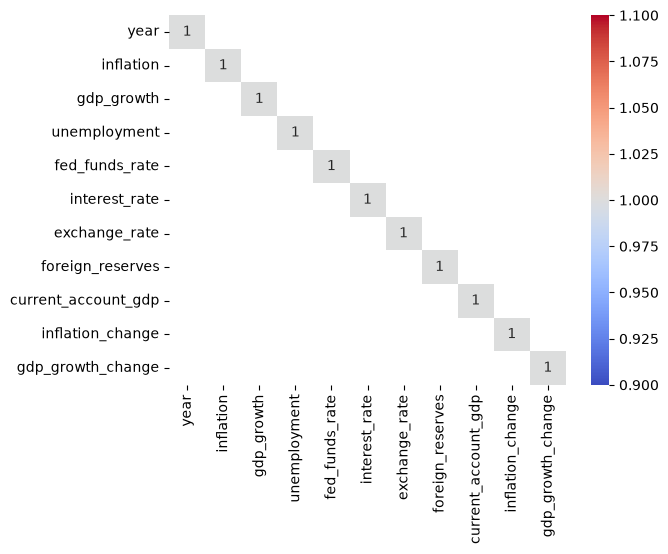

In [5335]:
sns.heatmap(corrilations, annot=True,mask=corrilations<.90, cmap='coolwarm')
#كده الداتا تمام مفيش عمودين بيعلموا نفس الحاجه

In [5336]:
ds_model = grid_xgb.best_estimator_

In [5337]:
# Get importances
# بالاسم اللي حطيته في الـ Pipeline ("clf")
importances = ds_model.named_steps["clf"].feature_importances_

In [5338]:
# # Print them alongside feature names
for name, score in zip(X.columns, importances):
    print(f"{name}: {score:.3f}")

year: 0.215
inflation: 0.145
gdp_growth: 0.133
unemployment: 0.073
fed_funds_rate: 0.065
interest_rate: 0.040
exchange_rate: 0.058
foreign_reserves: 0.029
current_account_gdp: 0.036
inflation_change: 0.061
gdp_growth_change: 0.144


In [5339]:
y_test_pred_xgb = ds_model.predict(X_test)
y_train_pred_xgb = ds_model.predict(X_train)

In [5340]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_xgb))
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_xgb))

Test Accuracy: 0.7839586028460543
Train Accuracy: 0.7847199741016511


In [5341]:
print("Classification Report for test:",classification_report(y_test, y_test_pred_xgb))
print("\n")
print("Classification Report for train:",classification_report(y_train, y_train_pred_xgb))

Classification Report for test:               precision    recall  f1-score   support

           0       0.87      0.83      0.85       585
           1       0.55      0.63      0.59       188

    accuracy                           0.78       773
   macro avg       0.71      0.73      0.72       773
weighted avg       0.80      0.78      0.79       773



Classification Report for train:               precision    recall  f1-score   support

           0       0.89      0.82      0.85      2338
           1       0.55      0.68      0.61       751

    accuracy                           0.78      3089
   macro avg       0.72      0.75      0.73      3089
weighted avg       0.81      0.78      0.79      3089



In [5342]:
# بالنسبة للداتا الحالية والتجارب اللي عملناها:

# أفضل Model: Decision Tree Classifier
# أفضل طريقة Fill Nulls: median  Imputation
#جربت الكود علي CLAUDE وي CHAT GPT

In [5344]:
import joblib# حدد المسار اللي عايز تحفظ فيه الموديل
save_path = r"best_model_xgb_optimization.joblib"

# حفظ النموذج
joblib.dump(grid_xgb, save_path)  

print(f"✅ Model saved successfully at: {save_path}")

✅ Model saved successfully at: best_model_xgb_optimization.joblib
